In [22]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

# <a target="_blank" href="https://colab.research.google.com/github/facebookresearch/sam3/blob/main/notebooks/sam3_image_interactive.ipynb">
#   <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
# </a>

In [23]:
using_colab = False

In [24]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib scikit-learn
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam3.git'

In [25]:
# Prefer interactive widgets when available; fallback to inline if ipympl is missing.
try:
    get_ipython().run_line_magic("matplotlib", "widget")
except RuntimeError:
    get_ipython().run_line_magic("matplotlib", "inline")
    print("`%matplotlib widget` unavailable in this environment; using `%matplotlib inline`.")

`%matplotlib widget` unavailable in this environment; using `%matplotlib inline`.


In [26]:
import torch
# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook. If your card doesn't support it, try float16 instead
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

# inference mode for the whole notebook. Disable if you need gradients
torch.inference_mode().__enter__()

# Load the model

In [27]:
import os
import sys
import subprocess
from pathlib import Path


def _find_local_sam3_repo(start_dir: Path) -> Path | None:
    """Find local SAM3 repo root that contains pyproject.toml and package source."""
    for p in [start_dir, *start_dir.parents]:
        nested_repo = p / "sam3"
        if (nested_repo / "pyproject.toml").exists() and (nested_repo / "sam3" / "__init__.py").exists():
            return nested_repo
        if (p / "pyproject.toml").exists() and (p / "sam3" / "__init__.py").exists():
            return p
    return None


sam3_repo = _find_local_sam3_repo(Path.cwd().resolve())
if sam3_repo is not None and str(sam3_repo) not in sys.path:
    sys.path.insert(0, str(sam3_repo))

try:
    import sam3
except ModuleNotFoundError:
    if sam3_repo is None:
        raise ModuleNotFoundError(
            "Could not find a local SAM3 repo. Install SAM3 first, e.g. `pip install -e /path/to/sam3`."
        )
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", str(sam3_repo)])
    import sam3

from sam3 import build_sam3_image_model

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")
bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"

In [28]:
model = build_sam3_image_model(bpe_path=bpe_path)

In [29]:
from sam3.model.sam3_image_processor import Sam3Processor
processor = Sam3Processor(model)

# Jupyter widget

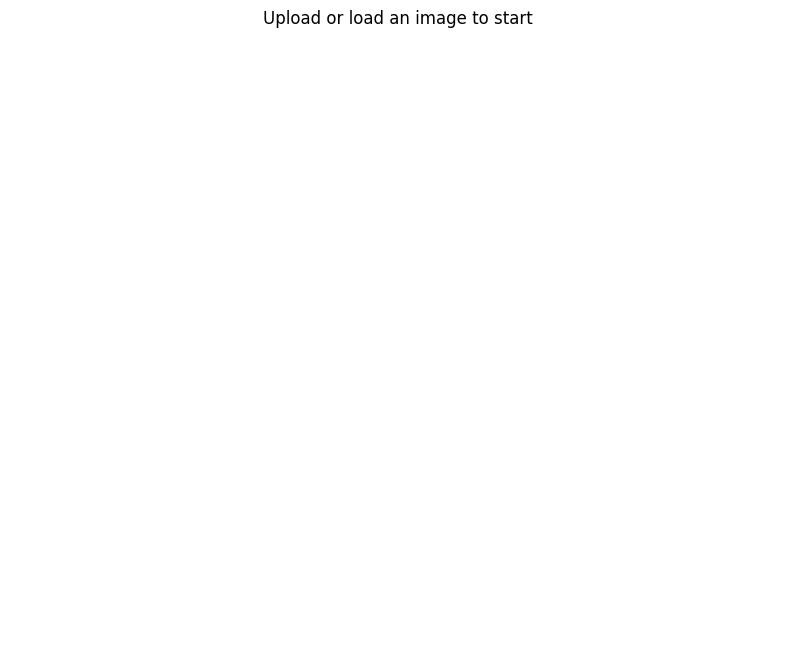

In [30]:
import io
import sys
import subprocess

try:
    import ipywidgets as widgets
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ipywidgets"])
    import ipywidgets as widgets

import matplotlib.pyplot as plt
import numpy as np
import PIL.Image
import requests
from IPython.display import clear_output, display, HTML, Image as IPyImage
from matplotlib.patches import Rectangle


class Sam3SegmentationWidget:
    """Interactive Jupyter widget for SAM3 segmentation with text and box prompts."""

    def __init__(self, processor):
        """
        Initialize the segmentation widget.

        Args:
            processor: Sam3Processor instance
        """
        self.processor = processor
        self.state = None
        self.current_image = None
        self.current_image_array = None
        self.box_mode = "positive"
        self.drawing_box = False
        self.box_start = None
        self.current_rect = None

        self._setup_ui()
        self._setup_plot()

    def _setup_ui(self):
        """Set up the UI components."""
        self.upload_widget = widgets.FileUpload(
            accept="image/*", multiple=False, description="Upload Image"
        )
        self.upload_widget.observe(self._on_image_upload, names="value")

        self.url_input = widgets.Text(
            value="",
            placeholder="Enter image URL",
            description="Image URL:",
            layout=widgets.Layout(width="500px"),
        )

        self.load_url_button = widgets.Button(
            description="Load from URL", button_style="info"
        )
        self.load_url_button.on_click(self._on_load_url)

        self.text_prompt = widgets.Text(
            value="",
            placeholder="Enter text prompt (e.g., 'cat', 'person')",
            description="Text:",
            layout=widgets.Layout(width="500px"),
        )

        self.box_mode_toggle = widgets.ToggleButtons(
            options=[("Positive Box", "positive"), ("Negative Box", "negative")],
            value="positive",
            description="Box Mode:",
            button_style="",
            tooltips=[
                "Add regions matching this box",
                "Exclude regions matching this box",
            ],
        )
        self.box_mode_toggle.observe(self._on_box_mode_change, names="value")

        self.clear_boxes_button = widgets.Button(
            description="Clear Boxes", button_style="warning"
        )
        self.clear_boxes_button.on_click(self._on_clear_boxes)

        self.segment_button = widgets.Button(
            description="Segment", button_style="success"
        )
        self.segment_button.on_click(self._on_segment)

        self.clear_results_button = widgets.Button(
            description="Clear Results", button_style="danger"
        )
        self.clear_results_button.on_click(self._on_clear_results)

        self.status_output = widgets.Output()
        self.controls_output = widgets.Output()
        self.figure_output = widgets.Output()

        self.pos_boxes = []
        self.neg_boxes = []

    def _setup_plot(self):
        """Set up matplotlib figure for image display and box drawing."""
        self.fig, self.ax = plt.subplots(figsize=(10, 8))
        self.ax.set_title("Upload or load an image to start")
        self.ax.axis("off")

        self.fig.canvas.mpl_connect("button_press_event", self._on_mouse_press)
        self.fig.canvas.mpl_connect("button_release_event", self._on_mouse_release)
        self.fig.canvas.mpl_connect("motion_notify_event", self._on_mouse_motion)

    def _render_figure_output(self):
        """Render figure in a widget output so image is visible even without interactive canvas support."""
        buf = io.BytesIO()
        self.fig.savefig(buf, format="png", bbox_inches="tight")
        buf.seek(0)
        with self.figure_output:
            clear_output(wait=True)
            display(IPyImage(data=buf.getvalue()))

    def _on_box_mode_change(self, change):
        """Handle box mode toggle change."""
        self.box_mode = change["new"]
        with self.status_output:
            clear_output(wait=True)
            print(f"Switched to {self.box_mode} box mode")

    def _on_image_upload(self, change):
        """Handle uploaded image."""
        if self.upload_widget.value:
            value = self.upload_widget.value
            uploaded_file = None
            if isinstance(value, dict):
                uploaded_file = next(iter(value.values()))
            elif isinstance(value, (list, tuple)) and len(value) > 0:
                uploaded_file = value[0]

            if uploaded_file is None:
                return

            if isinstance(uploaded_file, dict):
                image_data = uploaded_file.get("content")
            else:
                image_data = getattr(uploaded_file, "content", None)

            if image_data is None:
                with self.status_output:
                    clear_output(wait=True)
                    print("Unsupported upload format from ipywidgets.")
                return

            self._load_image_from_bytes(image_data)

    def _on_load_url(self, button):
        """Handle loading image from URL."""
        url = self.url_input.value.strip()
        if not url:
            with self.status_output:
                clear_output(wait=True)
                print("Please enter a URL")
            return

        try:
            response = requests.get(url, timeout=10)
            response.raise_for_status()
            self._load_image_from_bytes(response.content)
        except Exception as e:
            with self.status_output:
                clear_output(wait=True)
                print(f"Error loading image from URL: {str(e)}")

    def _load_image_from_bytes(self, image_bytes):
        """Load image from bytes data."""
        try:
            self.current_image = PIL.Image.open(io.BytesIO(image_bytes)).convert("RGB")
            self.current_image_array = np.array(self.current_image)

            self.state = self.processor.set_image(self.current_image)

            self._display_image()
            self.pos_boxes = []
            self.neg_boxes = []

            with self.status_output:
                clear_output(wait=True)
                print(
                    f"Image loaded successfully! Size: {self.current_image.size[0]}x{self.current_image.size[1]}"
                )

        except Exception as e:
            with self.status_output:
                clear_output(wait=True)
                print(f"Error processing image: {str(e)}")

    def load_image_from_path(self, image_path):
        """Fallback helper for environments where widget upload control is not visible."""
        from pathlib import Path

        image_bytes = Path(image_path).read_bytes()
        self._load_image_from_bytes(image_bytes)

    def segment_with_prompts(self, text="", pos_boxes=None, neg_boxes=None):
        """Fallback helper to run segmentation directly from Python code."""
        if pos_boxes is not None:
            self.pos_boxes = [list(box) for box in pos_boxes]
        if neg_boxes is not None:
            self.neg_boxes = [list(box) for box in neg_boxes]
        self.text_prompt.value = text
        self._on_segment(None)

    def _display_image(self):
        """Display current image with boxes."""
        self.ax.clear()
        if self.current_image_array is not None:
            self.ax.imshow(self.current_image_array)
            self.ax.set_title(
                f"Image loaded - Draw {self.box_mode} boxes by dragging mouse"
            )

            for box in self.pos_boxes:
                x1, y1, x2, y2 = box
                rect = Rectangle(
                    (x1, y1),
                    x2 - x1,
                    y2 - y1,
                    linewidth=2,
                    edgecolor="green",
                    facecolor="none",
                    alpha=0.8,
                )
                self.ax.add_patch(rect)

            for box in self.neg_boxes:
                x1, y1, x2, y2 = box
                rect = Rectangle(
                    (x1, y1),
                    x2 - x1,
                    y2 - y1,
                    linewidth=2,
                    edgecolor="red",
                    facecolor="none",
                    alpha=0.8,
                )
                self.ax.add_patch(rect)

            self.ax.legend(
                [
                    Rectangle((0, 0), 1, 1, facecolor="none", edgecolor="green"),
                    Rectangle((0, 0), 1, 1, facecolor="none", edgecolor="red"),
                ],
                ["Positive boxes", "Negative boxes"],
                loc="upper right",
            )

        self.ax.axis("off")
        self.fig.canvas.draw()
        self._render_figure_output()

    def _on_mouse_press(self, event):
        """Handle mouse press for box drawing."""
        if event.inaxes != self.ax or self.current_image_array is None:
            return

        self.drawing_box = True
        self.box_start = (event.xdata, event.ydata)

    def _on_mouse_motion(self, event):
        """Handle mouse motion during box drawing."""
        if (
            not self.drawing_box
            or self.box_start is None
            or event.inaxes != self.ax
            or event.xdata is None
            or event.ydata is None
        ):
            return

        if self.current_rect is not None:
            self.current_rect.remove()

        x1, y1 = self.box_start
        x2, y2 = event.xdata, event.ydata

        self.current_rect = Rectangle(
            (min(x1, x2), min(y1, y2)),
            abs(x2 - x1),
            abs(y2 - y1),
            linewidth=2,
            edgecolor="green" if self.box_mode == "positive" else "red",
            facecolor="none",
            linestyle="--",
            alpha=0.7,
        )
        self.ax.add_patch(self.current_rect)
        self.fig.canvas.draw()

    def _on_mouse_release(self, event):
        """Handle mouse release to finalize box."""
        if (
            not self.drawing_box
            or self.box_start is None
            or event.inaxes != self.ax
            or event.xdata is None
            or event.ydata is None
        ):
            self.drawing_box = False
            self.box_start = None
            return

        x1, y1 = self.box_start
        x2, y2 = event.xdata, event.ydata

        box = [min(x1, x2), min(y1, y2), max(x1, x2), max(y1, y2)]

        if abs(box[2] - box[0]) > 5 and abs(box[3] - box[1]) > 5:
            if self.box_mode == "positive":
                self.pos_boxes.append(box)
            else:
                self.neg_boxes.append(box)

            with self.status_output:
                clear_output(wait=True)
                print(
                    f"Added {self.box_mode} box: [{box[0]:.0f}, {box[1]:.0f}, {box[2]:.0f}, {box[3]:.0f}]"
                )

        self.drawing_box = False
        self.box_start = None
        if self.current_rect is not None:
            self.current_rect.remove()
            self.current_rect = None

        self._display_image()

    def _on_clear_boxes(self, button):
        """Clear all drawn boxes."""
        self.pos_boxes = []
        self.neg_boxes = []
        self._display_image()

        with self.status_output:
            clear_output(wait=True)
            print("All boxes cleared")

    def _on_segment(self, button):
        """Run segmentation with current prompts."""
        if self.state is None:
            with self.status_output:
                clear_output(wait=True)
                print("Please load an image first")
            return

        text = self.text_prompt.value.strip()
        if not text and not self.pos_boxes:
            with self.status_output:
                clear_output(wait=True)
                print("Please provide either text prompt or positive boxes")
            return

        try:
            with self.status_output:
                clear_output(wait=True)
                print("Running segmentation...")

            self.processor.reset_all_prompts(self.state)

            with torch.inference_mode():
                if text:
                    self.state = self.processor.set_text_prompt(text, self.state)

                img_w, img_h = self.current_image.size
                for box in self.pos_boxes:
                    x1, y1, x2, y2 = box
                    cx = ((x1 + x2) / 2.0) / img_w
                    cy = ((y1 + y2) / 2.0) / img_h
                    w = abs(x2 - x1) / img_w
                    h = abs(y2 - y1) / img_h
                    self.state = self.processor.add_geometric_prompt(
                        [cx, cy, w, h], True, self.state
                    )

                for box in self.neg_boxes:
                    x1, y1, x2, y2 = box
                    cx = ((x1 + x2) / 2.0) / img_w
                    cy = ((y1 + y2) / 2.0) / img_h
                    w = abs(x2 - x1) / img_w
                    h = abs(y2 - y1) / img_h
                    self.state = self.processor.add_geometric_prompt(
                        [cx, cy, w, h], False, self.state
                    )

            output = self.state

            self._display_results(output)

            with self.status_output:
                clear_output(wait=True)
                print(
                    f"Segmentation complete! Found {len(output.get('masks', []))} masks"
                )

        except Exception as e:
            with self.status_output:
                clear_output(wait=True)
                print(f"Segmentation error: {str(e)}")

    def _display_results(self, output):
        """Display segmentation results."""
        self.ax.clear()
        self.ax.imshow(self.current_image_array)
        self.ax.set_title("Segmentation Results")

        if "masks" in output and len(output["masks"]) > 0:
            masks = output["masks"]
            scores = output.get("scores", [1.0] * len(masks))

            colors = [
                [1, 0, 0, 0.5],
                [0, 1, 0, 0.5],
                [0, 0, 1, 0.5],
                [1, 1, 0, 0.5],
                [1, 0, 1, 0.5],
                [0, 1, 1, 0.5],
            ]

            for i, mask in enumerate(masks):
                mask_array = mask.cpu().numpy() if torch.is_tensor(mask) else mask
                if mask_array.ndim > 2:
                    mask_array = mask_array.squeeze()

                color = colors[i % len(colors)]
                overlay = np.zeros((*mask_array.shape, 4))
                overlay[mask_array > 0] = color
                self.ax.imshow(overlay)

                if len(scores) > i:
                    y_pos = 30 + i * 25
                    self.ax.text(
                        10,
                        y_pos,
                        f"Mask {i + 1}: {scores[i]:.3f}",
                        color="white",
                        fontsize=10,
                        bbox=dict(facecolor="black", alpha=0.7),
                    )

        for box in self.pos_boxes:
            x1, y1, x2, y2 = box
            rect = Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor="green",
                facecolor="none",
                alpha=0.8,
            )
            self.ax.add_patch(rect)

        for box in self.neg_boxes:
            x1, y1, x2, y2 = box
            rect = Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor="red",
                facecolor="none",
                alpha=0.8,
            )
            self.ax.add_patch(rect)

        self.ax.axis("off")
        self.fig.canvas.draw()
        self._render_figure_output()

    def _on_clear_results(self, button):
        """Clear segmentation results and return to box drawing mode."""
        self._display_image()
        with self.status_output:
            clear_output(wait=True)
            print("Results cleared")

    def display(self):
        """Display the complete widget interface."""
        controls = widgets.VBox(
            [
                widgets.HTML("<h3>SAM3 Interactive Segmentation</h3>"),
                widgets.HBox([self.upload_widget]),
                widgets.HBox([self.url_input, self.load_url_button]),
                self.text_prompt,
                self.box_mode_toggle,
                widgets.HBox(
                    [
                        self.clear_boxes_button,
                        self.segment_button,
                        self.clear_results_button,
                    ]
                ),
                self.figure_output,
                self.status_output,
            ]
        )

        display(controls)
        self._render_figure_output()


widget = Sam3SegmentationWidget(processor)

# Run!

If controls are not visible, use fallback API:
1) widget.load_image_from_path('/absolute/path/to/image.jpg')
2) widget.segment_with_prompts(text='person', pos_boxes=[[50, 60, 300, 400]], neg_boxes=[])


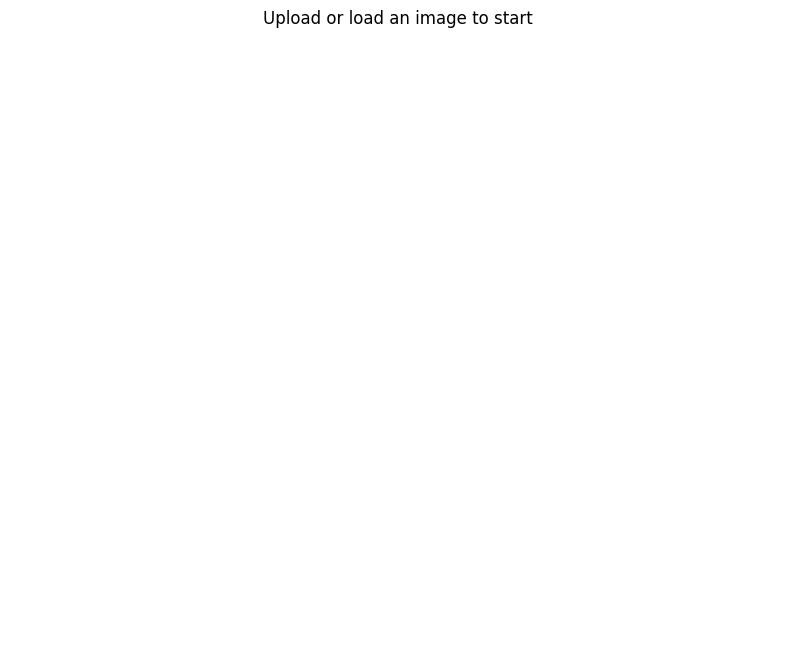

In [ ]:
widget = Sam3SegmentationWidget(processor)
widget.display()

print("If controls are not visible, use fallback API:")
print("1) widget.load_image_from_path('/absolute/path/to/image.jpg')")
print("2) widget.segment_with_prompts(text='person', pos_boxes=[[50, 60, 300, 400]], neg_boxes=[])")

In [32]:
from pathlib import Path

# Demo fallback run: load a local image and run segmentation without relying on widget buttons.
candidate_images = []
for base in [Path.cwd(), *Path.cwd().parents]:
    candidate_images.extend(
        [
            base / '.venv/lib/python3.10/site-packages/gradio/test_data/lion.jpg',
            base / '.venv/lib/python3.10/site-packages/gradio/test_data/cheetah1.jpg',
            base / '.venv/lib/python3.10/site-packages/gradio/test_data/test_image.png',
        ]
    )

img_path = next((p for p in candidate_images if p.exists()), None)
if img_path is None:
    print('No local demo image found. Use: widget.load_image_from_path("/absolute/path/to/image.jpg")')
else:
    widget.load_image_from_path(str(img_path))
    widget.segment_with_prompts(text='animal')
    print(f'Loaded demo image: {img_path}')

Loaded demo image: /mnt/e/side_projects/efficientsam3/.venv/lib/python3.10/site-packages/gradio/test_data/lion.jpg
